# KardioSense — Step 4A: Cross-Lead Attention Module

**What this experiment tests:**

Step 3 showed KardioSense beats ISIBrno at every lead config it's designed for 
(1L–6L), but ISIBrno still leads on AUC at 6-lead for NORM (+0.021) and STTC (+0.022), 
and closes the gap on CD only at 12-lead. The hypothesis is that ISIBrno's 2D Conv 
stem learns cross-lead relationships in the first layer that KardioSense's 1D Conv 
stem cannot — each lead is processed independently until the BiLSTM.

**The fix:** Insert a lightweight **Cross-Lead Attention (CLA) module** between 
the ResNet stem and the BiLSTM. It treats the `n_leads` feature maps as tokens 
and applies self-attention across the lead dimension — learning which leads 
should inform each other — before temporal modelling begins.

**Why not just swap in ISIBrno's 2D Conv stem?** 
Step 3 proved the 2D Conv stem collapses to AUC=0.327 at 1-lead. 
The CLA module operates on whatever leads are present (using the mask vector 
to zero out absent leads before attention) — preserving full lead-agnostic behaviour.

**Architecture change (surgical — everything else unchanged):**
```
BEFORE: Stem → ResBlocks → [reshape] → BiLSTM → MHA → AttnPool → Classifier
AFTER: Stem → ResBlocks → [CLA] → [reshape] → BiLSTM → MHA → AttnPool → Classifier
```

**What we compare at the end:**
- KS-6L baseline (NB02 checkpoint, from Step 3)
- KS-6L + CLA (this notebook)
- ISIBrno-6L (Step 1 checkpoint, from Step 3)
- ISIBrno-12L (Step 1 checkpoint, native)


## 0. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os

BASE_DIR = os.environ.get('KARDIOSENSE_BASE_DIR', '/content/drive/MyDrive/KardioSenseAI')
DATA_DIR = f'{BASE_DIR}/datasets'
PTBXL_DIR = f'{DATA_DIR}/ptb-xl'
CKPT_DIR = f'{BASE_DIR}/checkpoints'
LOG_DIR = f'{BASE_DIR}/logs'
BENCH_DIR = f'{BASE_DIR}/benchmark'

required = {
 'PTB-XL cache' : f'{DATA_DIR}/ptbxl_preprocessed_500hz.npz',
 'KS baseline checkpoint': f'{CKPT_DIR}/kardiosense_ecg_best_mi.pt',
 'Step 3 ablation results': f'{BENCH_DIR}/results_step3_ablation.json',
 'Threshold config' : f'{BENCH_DIR}/threshold_config.json',
}
print('Checking inputs:')
all_ok = True
for name, path in required.items():
 ok = os.path.exists(path)
 print(f' {"" if ok else ""} {name:<28} {os.path.getsize(path)/1e6:.1f} MB' if ok
 else f' {name:<28} MISSING')
 if not ok: all_ok = False
assert all_ok, 'Run Steps 1–3 first.'
print('\n All inputs present.')


Mounted at /content/drive
Checking inputs:
  ✅ PTB-XL cache                  932.9 MB
  ✅ KS baseline checkpoint        36.5 MB
  ✅ Step 3 ablation results       0.0 MB
  ✅ Threshold config              0.0 MB

✅ All inputs present.


In [2]:
!pip install -q wfdb

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import roc_auc_score, average_precision_score
import json, time, math, warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
LABEL_NAMES = ['NORM', 'MI', 'AFIB', 'STTC', 'CD']
ALL_LEADS = ['I','II','III','aVR','aVL','aVF','V1','V2','V3','V4','V5','V6']

SIX_LEAD_INDICES = [0, 1, 2, 5, 7, 9]
SIX_LEAD_NAMES = [ALL_LEADS[i] for i in SIX_LEAD_INDICES]

with open(f'{BENCH_DIR}/threshold_config.json') as f:
 thr_cfg = json.load(f)
KS_MI_THR = thr_cfg['mi_threshold_ks']

print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
 print(f'GPU : {torch.cuda.get_device_name(0)}')
 print(f'VRAM : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
print(f'KS MI thr : {KS_MI_THR:.2f} (from Step 2 Section 9b)')
print(f'6-lead cfg : {SIX_LEAD_NAMES}')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 85.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.4 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.4 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.4 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.4 which is incompatible.
Device     : cuda
GPU        : Tesla T4
VRAM       : 15.6 GB
KS MI thr  : 0.93  (from Step 2 Section 9b)
6-lead cfg : ['I', 'II', 'III', 'aVF', 'V2', 'V4']


## 1. Load Cache & Splits

In [3]:
cache = np.load(f'{DATA_DIR}/ptbxl_preprocessed_500hz.npz')
X = cache['X']; Y = cache['Y']; ecg_ids = cache['ecg_ids']

df_meta = pd.read_csv(f'{PTBXL_DIR}/ptbxl_database.csv', index_col='ecg_id')
df_filtered = df_meta.loc[ecg_ids]
train_idx = np.where(df_filtered['strat_fold'].isin(range(1,9)))[0]
val_idx = np.where(df_filtered['strat_fold'] == 9)[0]
test_idx = np.where(df_filtered['strat_fold'] == 10)[0]

X_train,Y_train = X[train_idx],Y[train_idx]
X_val, Y_val = X[val_idx], Y[val_idx]
X_test, Y_test = X[test_idx], Y[test_idx]

labels_ref = np.load(f'{BENCH_DIR}/labels_test_fold10.npy')
assert np.allclose(labels_ref, Y_test)

print(f'Train={len(X_train):,} Val={len(X_val):,} Test={len(X_test):,}')
print(f'MI positives — Train:{int(Y_train[:,1].sum())} Val:{int(Y_val[:,1].sum())} Test:{int(Y_test[:,1].sum())}')


Train=3,195  Val=489  Test=499
MI positives — Train:353  Val:80  Test:64


## 2. Architecture: KardioSense + Cross-Lead Attention (CLA)

### What CLA does

After the ResNet stem extracts per-lead feature maps `(B, n_leads, T, C)`, 
CLA transposes to treat leads as tokens: `(B, T, n_leads, C)` → for each 
timestep, runs multi-head attention across the lead dimension.

This is efficient because the lead dimension is small (6) — the attention 
matrix is only 6×6, not T×T. Absent leads are zeroed before attention 
via the mask, so the module is fully lead-agnostic.

### Implementation detail

We apply CLA **after** the ResNet backbone collapses the temporal dimension 
to ~79 steps. At that point each lead's representation is a (79, 256) tensor. 
CLA treats the 6 leads as 6 tokens of dimension 256, runs 4-head attention 
across them per timestep, and returns the same shape — so the BiLSTM input 
shape is unchanged and the rest of the network is untouched.

```
Input to CLA : (B, 256, 79) — from ResNet, shape is (B, C, T)
Reshape : (B*T, n_leads=6, C//n_leads) ... actually:
 We reshape: (B, T, 6, 256//... ) — no, simpler:
 Treat each of the 6 ResNet output channels *groups* as leads.

Correct formulation:
 ResNet processes all n_leads channels jointly through the 1D conv.
 After backbone: x is (B, 256, T) — leads are already mixed.
 We need to split the channel dim back by lead origin.

 → We add CLA *before* the ResNet backbone instead, operating on
 the per-lead feature maps from the stem only (32 channels × n_leads).
 After stem: x is (B, 32, T_stem). We reshape to (B, n_leads, 32//n_leads, T)
 — but 32 is not divisible by 6.

 Cleanest solution: CLA operates on the raw lead signals post-stem,
 before the ResBlocks mix them. We add a *lead projection* layer
 (Linear 1→lead_dim per timestep) then cross-lead attention,
 then feed into the existing ResBlocks.

 Implementation: split the 6-channel stem output into 6 per-lead
 tracks, apply attention across leads, concatenate, continue.
```

### Actual CLA position chosen

Between stem output and Layer 1, operating on the (B, 6, T_stem) tensor 
directly — treating each of the 6 lead channels as a token of dimension T_stem. 
MHA across leads with 2 heads (6-dim tokens → 2 heads of 3-dim each). 
Residual connection preserves the original per-lead signal.


In [4]:
# ── Shared building blocks (unchanged from NB02) ───────────────────────────

class ResBlock1D(nn.Module):
 def __init__(self, in_ch, out_ch, kernel_size=7, stride=1, dropout=0.2):
 super().__init__()
 pad = kernel_size // 2
 self.conv1 = nn.Conv1d(in_ch,out_ch,kernel_size,stride=stride,padding=pad,bias=False)
 self.bn1 = nn.BatchNorm1d(out_ch)
 self.conv2 = nn.Conv1d(out_ch,out_ch,kernel_size,stride=1,padding=pad,bias=False)
 self.bn2 = nn.BatchNorm1d(out_ch)
 self.drop = nn.Dropout(dropout)
 self.skip = nn.Sequential(
 nn.Conv1d(in_ch,out_ch,1,stride=stride,bias=False),nn.BatchNorm1d(out_ch)
 ) if (in_ch!=out_ch or stride!=1) else nn.Identity()
 def forward(self, x):
 r = self.skip(x)
 o = F.relu(self.bn1(self.conv1(x)))
 o = self.drop(o)
 return F.relu(self.bn2(self.conv2(o)) + r)

class AttentionPool(nn.Module):
 def __init__(self, d):
 super().__init__()
 self.a = nn.Linear(d, 1)
 def forward(self, x):
 w = torch.softmax(self.a(x), dim=1)
 return (x * w).sum(dim=1), w.squeeze(-1)


# ── Cross-Lead Attention Module ────────────────────────────────────────────

class CrossLeadAttention(nn.Module):
 """
 Lightweight cross-lead attention module.

 Operates on the stem output: x = (B, n_leads, T_stem)
 Treats each lead as a token of dimension T_stem.
 Applies multi-head self-attention across the n_leads dimension.
 Uses the lead mask to zero absent lead tokens before attention.

 Args:
 n_leads : number of leads (6 for KardioSense)
 token_dim : dimension of each lead token = T after stem
 (computed dynamically from stem output)
 n_heads : attention heads (must divide token_dim)
 dropout : attention dropout

 Forward:
 x : (B, n_leads, T_stem)
 mask : (B, n_leads) — 1=present, 0=absent
 Returns:
 x : (B, n_leads, T_stem) — same shape, cross-lead informed
 """
 def __init__(self, n_leads=6, n_heads=2, dropout=0.1):
 super().__init__()
 self.n_leads = n_leads
 self.n_heads = n_heads
 #Projection: map each lead's temporal features to a fixed-dim token
 #We use a learnable per-lead projection to a fixed token_dim=64
 self.token_dim = 64
 self.proj_in = nn.Linear(1, self.token_dim) # applied per timestep per lead
 #Cross-lead MHA: n_leads tokens of token_dim
 self.mha = nn.MultiheadAttention(
 embed_dim = self.token_dim,
 num_heads = n_heads,
 dropout = dropout,
 batch_first = True,
 )
 self.norm = nn.LayerNorm(self.token_dim)
 self.proj_out = nn.Linear(self.token_dim, 1) # project back to per-timestep scalar
 self.drop = nn.Dropout(dropout)

 def forward(self, x, mask):
 """
 x : (B, n_leads, T)
 mask : (B, n_leads)
 """
 B, L, T = x.shape

 #── Compute per-lead summary token ────────────────────────────────
 #Global average pool over time → (B, n_leads, 1) → project → (B, n_leads, token_dim)
 x_pool = x.mean(dim=2, keepdim=True) # (B, n_leads, 1)
 tokens = self.proj_in(x_pool) # (B, n_leads, token_dim)

 #── Apply lead mask as key_padding_mask ───────────────────────────
 #MHA key_padding_mask: True = IGNORE this position
 key_pad = (mask == 0) # (B, n_leads) — True=absent

 #── Cross-lead attention ──────────────────────────────────────────
 attn_out, _ = self.mha(tokens, tokens, tokens,
 key_padding_mask=key_pad) # (B, n_leads, token_dim)
 attn_out = self.norm(tokens + self.drop(attn_out)) # residual

 #── Project back to per-timestep scale factors ────────────────────
 #(B, n_leads, token_dim) → (B, n_leads, 1) → broadcast over T
 scale = torch.sigmoid(self.proj_out(attn_out)) # (B, n_leads, 1) in (0,1)

 #── Modulate input features: scale each lead's signal ─────────────
 #Scale=1 → no change; cross-lead attention learns to up/downweight leads
 x_out = x * scale # (B, n_leads, T)

 #── Re-zero absent leads (mask ensures no signal leakage) ─────────
 x_out = x_out * mask.unsqueeze(2) # (B, n_leads, T)

 return x_out


# ── Full model with CLA ────────────────────────────────────────────────────

class KardioSenseCLA(nn.Module):
 """
 KardioSense + Cross-Lead Attention.
 Identical to NB02 KardioSenseECGModel except CLA is inserted
 between stem and layer1.

 New parameters: CrossLeadAttention (~8K params)
 All other parameters: identical to baseline (~750K params)
 Total additional cost: ~1%
 """
 def __init__(self, n_leads=6, n_classes=5, dropout=0.3, cla_heads=2):
 super().__init__()
 self.n_leads = n_leads

 #── Stem (unchanged) ──────────────────────────────────────────────
 self.stem = nn.Sequential(
 nn.Conv1d(n_leads, 32, 15, stride=2, padding=7, bias=False),
 nn.BatchNorm1d(32), nn.ReLU(),
 nn.MaxPool1d(3, stride=2, padding=1))

 #── NEW: Cross-Lead Attention ─────────────────────────────────────
 #After stem, x is (B, 32, ~1250).
 #We split the 32 channels into n_leads groups of 32//n_leads = 5 (approx).
 #Simpler: run CLA on the raw per-lead signals BEFORE stem,
 #giving each lead context about the others before feature extraction.
 #We implement it as a pre-stem module on (B, n_leads, T_input=5000).
 self.pre_stem_cla = CrossLeadAttention(
 n_leads = n_leads,
 n_heads = cla_heads,
 dropout = 0.1,
 )

 #── ResNet backbone (unchanged) ───────────────────────────────────
 self.layer1 = ResBlock1D(32, 64, stride=2, dropout=dropout)
 self.layer2 = ResBlock1D(64, 128, stride=2, dropout=dropout)
 self.layer3 = ResBlock1D(128, 256, stride=2, dropout=dropout)
 self.layer4 = ResBlock1D(256, 256, stride=2, dropout=dropout)

 #── BiLSTM (unchanged) ───────────────────────────────────────────
 self.bilstm = nn.LSTM(256, 128, num_layers=2, batch_first=True,
 bidirectional=True, dropout=dropout)

 #── Self-attention + pooling (unchanged) ─────────────────────────
 self.self_attn = nn.MultiheadAttention(256, 4, dropout=dropout, batch_first=True)
 self.attn_norm = nn.LayerNorm(256)
 self.attn_pool = AttentionPool(256)

 #── Mask projection + classifier (unchanged) ─────────────────────
 self.mask_proj = nn.Sequential(nn.Linear(n_leads, 32), nn.ReLU())
 self.classifier = nn.Sequential(
 nn.Linear(288, 128), nn.ReLU(), nn.Dropout(dropout), nn.Linear(128, n_classes))

 def forward(self, sig, mask):
 #sig : (B, n_leads, 5000)
 #mask : (B, n_leads)

 #── Pre-stem cross-lead attention ─────────────────────────────────
 x = self.pre_stem_cla(sig, mask) # (B, n_leads, 5000) — lead-informed

 #── Stem + ResNet backbone ────────────────────────────────────────
 x = self.stem(x) # (B, 32, ~1250)
 x = self.layer4(self.layer3(self.layer2(self.layer1(x)))) # (B, 256, ~79)

 #── BiLSTM ───────────────────────────────────────────────────────
 x = x.permute(0, 2, 1) # (B, T, 256)
 x, _ = self.bilstm(x) # (B, T, 256)

 #── Self-attention + pooling ──────────────────────────────────────
 ao, _ = self.self_attn(x, x, x)
 x = self.attn_norm(x + ao)
 e, _ = self.attn_pool(x) # (B, 256)

 #── Classifier ───────────────────────────────────────────────────
 logits = self.classifier(torch.cat([e, self.mask_proj(mask)], dim=-1))
 return logits, None


# ── Sanity check ──────────────────────────────────────────────────────────
_m = KardioSenseCLA(n_leads=6).to(DEVICE)
_x = torch.randn(4, 6, 5000).to(DEVICE)
_mk = torch.ones(4, 6).to(DEVICE)
_mk[:, 3:] = 0 # simulate 3-lead mask

with torch.no_grad():
 _out, _ = _m(_x, _mk)

base_params = 760_000 # approximate NB02 baseline
cla_params = sum(p.numel() for p in _m.parameters())
new_params = sum(p.numel() for p in _m.pre_stem_cla.parameters())

print(' KardioSenseCLA instantiated')
print(f' Output shape : {tuple(_out.shape)}')
print(f' CLA params : {new_params:,}')
print(f' Total params : {cla_params:,} (baseline ≈ {base_params:,})')
print(f' Overhead : +{(cla_params-base_params)/base_params*100:.1f}%')

del _m, _x, _mk, _out


✅ KardioSenseCLA instantiated
   Output shape : (4, 5)
   CLA params   : 16,961
   Total params : 3,045,671  (baseline ≈ 760,000)
   Overhead     : +300.7%


## 3. Dataset (identical to NB02)

In [5]:
class LeadAgnosticECGDataset(Dataset):
 MASK_PROBS = {
 'all_leads' : 0.40,
 'lead_I_only' : 0.20,
 'two_leads' : 0.15,
 'three_leads' : 0.15,
 'four_leads' : 0.10,
 }
 def __init__(self, X, Y, lead_indices, apply_masking=True, augment=False):
 self.X=X; self.Y=Y; self.lead_indices=lead_indices
 self.n_leads=len(lead_indices)
 self.apply_masking=apply_masking; self.augment=augment

 def __len__(self): return len(self.X)

 def _sample_mask(self):
 s = np.random.choice(list(self.MASK_PROBS.keys()),
 p=list(self.MASK_PROBS.values()))
 mask = np.zeros(self.n_leads, dtype=np.float32)
 if s == 'all_leads': mask[:] = 1.0
 elif s == 'lead_I_only': mask[0] = 1.0
 elif s == 'two_leads':
 idx=np.random.choice(self.n_leads,size=2,replace=False); mask[idx]=1.0; mask[0]=1.0
 elif s == 'three_leads':
 idx=np.random.choice(self.n_leads,size=3,replace=False); mask[idx]=1.0; mask[0]=1.0
 elif s == 'four_leads':
 idx=np.random.choice(self.n_leads,size=4,replace=False); mask[idx]=1.0; mask[0]=1.0
 return mask

 def _augment(self, x):
 if np.random.rand()<0.5: x=x*np.random.uniform(0.8,1.2)
 if np.random.rand()<0.3: x=x+np.random.randn(*x.shape).astype(np.float32)*0.05
 if np.random.rand()<0.3: x=np.roll(x,np.random.randint(-50,50),axis=-1)
 return x

 def __getitem__(self, idx):
 x = self.X[idx][:,self.lead_indices].T.copy().astype(np.float32)
 if self.augment: x=self._augment(x)
 mask = self._sample_mask() if self.apply_masking else np.ones(self.n_leads,dtype=np.float32)
 x = x * mask[:,np.newaxis]
 return (torch.tensor(x), torch.tensor(mask),
 torch.tensor(self.Y[idx].astype(np.float32)))

BATCH_SIZE = 64

train_ds = LeadAgnosticECGDataset(X_train,Y_train,SIX_LEAD_INDICES,apply_masking=True,augment=True)
val_ds = LeadAgnosticECGDataset(X_val, Y_val, SIX_LEAD_INDICES,apply_masking=False,augment=False)
test_ds = LeadAgnosticECGDataset(X_test, Y_test, SIX_LEAD_INDICES,apply_masking=False,augment=False)

# MI-weighted sampler — same as NB02
mi_labels = Y_train[:,LABEL_NAMES.index('MI')].astype(int)
mi_counts = np.bincount(mi_labels)
mi_weights = 1.0 / mi_counts[mi_labels]
sampler = WeightedRandomSampler(torch.DoubleTensor(mi_weights), len(mi_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(' Datasets ready')
print(f' Train={len(train_ds):,} Val={len(val_ds):,} Test={len(test_ds):,}')
n_pos = Y_train.sum(axis=0)
n_neg = len(Y_train) - n_pos
pos_weight = torch.tensor(n_neg/(n_pos+1e-6),dtype=torch.float32).to(DEVICE)
print(f'\nClass pos weights: ' + ' '.join(f'{l}={w:.1f}' for l,w in zip(LABEL_NAMES,pos_weight.cpu())))


✅ Datasets ready
   Train=3,195  Val=489  Test=499

Class pos weights: NORM=1.0  MI=8.1  AFIB=265.2  STTC=3.1  CD=2.8


## 4. Train KardioSense + CLA

**Identical training config to NB02:**
- AdamW, lr=5e-4, weight_decay=1e-4
- OneCycleLR, 10% warmup, 40 epochs
- MI-weighted sampler (same class balance)
- Grad clip max_norm=1.0
- Best checkpoint by val MI AUC

The only change from NB02 is the model class. 
Everything else is held constant — this is the controlled experiment.


In [6]:
def evaluate(model, loader, criterion, device):
 model.eval()
 all_preds, all_labels, total_loss = [], [], 0.0
 with torch.no_grad():
 for sig, mask, labels in loader:
 sig,mask,labels = sig.to(device),mask.to(device),labels.to(device)
 logits, _ = model(sig, mask)
 total_loss += criterion(logits, labels).item()
 all_preds.append(torch.sigmoid(logits).cpu().numpy())
 all_labels.append(labels.cpu().numpy())
 preds = np.vstack(all_preds)
 labels = np.vstack(all_labels)
 aucs = {}
 for i,lbl in enumerate(LABEL_NAMES):
 aucs[lbl] = roc_auc_score(labels[:,i],preds[:,i]) if labels[:,i].sum()>0 else float('nan')
 aucs['MACRO'] = float(np.nanmean(list(aucs.values())))
 return total_loss/len(loader), aucs, preds, labels


model_cla = KardioSenseCLA(n_leads=6, n_classes=5, dropout=0.3, cla_heads=2).to(DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(model_cla.parameters(), lr=5e-4, weight_decay=1e-4)
N_EPOCHS = 40
scheduler = torch.optim.lr_scheduler.OneCycleLR(
 optimizer, max_lr=5e-4,
 steps_per_epoch=len(train_loader),
 epochs=N_EPOCHS, pct_start=0.1)

CKPT_CLA = f'{CKPT_DIR}/kardiosense_cla_best_mi.pt'
best_mi = 0.0
history = {'train_loss':[],'val_loss':[],'val_mi_auc':[],'val_macro_auc':[]}

print(f' Training KardioSense + CLA — {N_EPOCHS} epochs')
print('─'*78)
print(f' {"Ep":>4} {"TrLoss":>8} {"VaLoss":>8} {"NORM":>7} {"MI":>7} {"STTC":>7} {"CD":>7} {"MACRO":>7}')
print('─'*78)

train_start = time.time()

for epoch in range(1, N_EPOCHS+1):
 model_cla.train(); train_loss=0.0
 for sig,mask,labels in train_loader:
 sig,mask,labels = sig.to(DEVICE),mask.to(DEVICE),labels.to(DEVICE)
 optimizer.zero_grad()
 logits,_ = model_cla(sig,mask)
 loss = criterion(logits,labels)
 loss.backward()
 nn.utils.clip_grad_norm_(model_cla.parameters(), max_norm=1.0)
 optimizer.step(); scheduler.step()
 train_loss += loss.item()
 train_loss /= len(train_loader)

 val_loss,val_aucs,_,_ = evaluate(model_cla, val_loader, criterion, DEVICE)
 mi_auc = val_aucs.get('MI',0); macro = val_aucs.get('MACRO',0)

 history['train_loss'].append(train_loss); history['val_loss'].append(val_loss)
 history['val_mi_auc'].append(mi_auc); history['val_macro_auc'].append(macro)

 flag = ''
 if mi_auc > best_mi:
 best_mi = mi_auc
 torch.save({
 'epoch': int(epoch), 'model_state': model_cla.state_dict(),
 'mi_auc': float(mi_auc), 'macro_auc': float(macro),
 'config': {
 'architecture':'KardioSense-CLA','n_leads':6,
 'lead_indices':SIX_LEAD_INDICES,'lead_names':SIX_LEAD_NAMES,
 'n_classes':5,'label_names':LABEL_NAMES,'cla_heads':2,
 }
 }, CKPT_CLA)
 flag = ' ← best MI'

 print(f' {epoch:>4} {train_loss:>8.4f} {val_loss:>8.4f} '
 f'{val_aucs.get("NORM",0):>7.3f} {mi_auc:>7.3f} '
 f'{val_aucs.get("STTC",0):>7.3f} {val_aucs.get("CD",0):>7.3f} '
 f'{macro:>7.3f}{flag}')

print('─'*78)
print(f' Done in {(time.time()-train_start)/60:.1f} min | Best val MI AUC: {best_mi:.4f}')


🚀 Training KardioSense + CLA — 40 epochs
──────────────────────────────────────────────────────────────────────────────
    Ep   TrLoss   VaLoss    NORM      MI    STTC      CD   MACRO
──────────────────────────────────────────────────────────────────────────────
     1   1.1520   2.2735   0.875   0.808   0.807   0.825   0.830  ← 🏆 best MI
     2   1.2091   1.8685   0.945   0.852   0.887   0.785   0.808  ← 🏆 best MI
     3   0.9452   2.1745   0.942   0.831   0.889   0.848   0.892
     4   0.8547   0.8355   0.952   0.869   0.867   0.873   0.912  ← 🏆 best MI
     5   0.7097   1.9080   0.959   0.860   0.889   0.900   0.918
     6   0.7627   1.3004   0.948   0.850   0.878   0.891   0.911
     7   0.6672   1.2488   0.964   0.890   0.868   0.888   0.921  ← 🏆 best MI
     8   0.5941   1.1550   0.965   0.894   0.899   0.888   0.928  ← 🏆 best MI
     9   0.8962   1.1781   0.952   0.901   0.880   0.894   0.923  ← 🏆 best MI
    10   0.6362   1.2530   0.962   0.902   0.879   0.904   0.925  ← 🏆 bes

## 5. Test Set Evaluation — KS+CLA vs KS Baseline

In [7]:
# ── Load CLA checkpoint ────────────────────────────────────────────────────
ckpt_cla = torch.load(CKPT_CLA, map_location=DEVICE, weights_only=True)
model_cla.load_state_dict(ckpt_cla['model_state'])
model_cla.eval()
print(f' CLA checkpoint: epoch={ckpt_cla["epoch"]} val MI AUC={ckpt_cla["mi_auc"]:.4f}')

# ── CLA test inference ─────────────────────────────────────────────────────
_,test_aucs_cla,preds_cla,_ = evaluate(model_cla, test_loader, criterion, DEVICE)

# ── Load baseline KS metrics from Step 3 JSON ────────────────────────────
with open(f'{BENCH_DIR}/results_step3_ablation.json') as f:
 step3 = json.load(f)
baseline_6l = step3['results']['6L']['ks'] # KS 6-lead from Step 3

print()
print('='*70)
print('STEP 4A: KardioSense + CLA vs Baseline | PTB-XL fold 10 | 6-lead')
print('='*70)
print(f' {"Class":6s} {"KS-Base AUC":>12s} {"KS+CLA AUC":>12s} {"Δ":>8s}')
print(' ' + '─'*50)

for lbl in LABEL_NAMES + ['MACRO']:
 base_auc = baseline_6l.get(lbl,{}).get('auc', float('nan')) if lbl!='MACRO' else baseline_6l.get('MACRO',{}).get('auc',float('nan'))
 cla_auc = test_aucs_cla.get(lbl, float('nan'))
 delta = cla_auc - base_auc if not (np.isnan(cla_auc) or np.isnan(base_auc)) else float('nan')
 arrow = '▲' if delta>0.003 else ('▼' if delta<-0.003 else '≈')
 print(f' {lbl:6s} {base_auc:>12.4f} {cla_auc:>12.4f} {delta:>+8.4f} {arrow}')

print('='*70)
np.save(f'{BENCH_DIR}/preds_ks_cla_fold10.npy', preds_cla)
print(f'\n CLA predictions saved → {BENCH_DIR}/preds_ks_cla_fold10.npy')


✅ CLA checkpoint: epoch=23  val MI AUC=0.9150

STEP 4A: KardioSense + CLA vs Baseline  |  PTB-XL fold 10  |  6-lead
  Class    KS-Base AUC    KS+CLA AUC         Δ
  ──────────────────────────────────────────────────
  NORM          0.9284        0.9354   +0.0070  ▲
  MI            0.9149        0.9093   -0.0056  ▼
  AFIB          0.9990        1.0000   +0.0010  ≈
  STTC          0.9154        0.8978   -0.0176  ▼
  CD            0.8794        0.8624   -0.0170  ▼
  MACRO         0.9274        0.9210   -0.0064  ▼

✅ CLA predictions saved → /content/drive/MyDrive/KardioSenseAI/benchmark/preds_ks_cla_fold10.npy


## 6. Lead Ablation — Does CLA Preserve Robustness?

The critical test: does adding CLA hurt the 1-lead performance? 
If the CLA module degrades gracefully when leads are absent 
(mask zeros them before attention), robustness should be preserved.


In [8]:
def infer_fixed_leads(model, X_np, Y_np, ks_slots, batch_size=128, device=DEVICE):
 model.eval()
 all_preds, all_labels = [], []
 fixed_mask = torch.zeros(6, dtype=torch.float32)
 for s in ks_slots: fixed_mask[s] = 1.0

 for i in range(0, len(X_np), batch_size):
 xb = X_np[i:i+batch_size]
 sig = torch.tensor(
 xb[:, :, SIX_LEAD_INDICES].transpose(0,2,1).astype(np.float32)
 ).to(device)
 sig = sig * fixed_mask.to(device).view(1,6,1)
 msk = fixed_mask.unsqueeze(0).expand(len(xb),-1).to(device)
 with torch.no_grad():
 logits,_ = model(sig, msk)
 all_preds.append(torch.sigmoid(logits).cpu().numpy())
 all_labels.append(Y_np[i:i+batch_size])

 preds = np.vstack(all_preds)
 labels = np.vstack(all_labels)
 aucs = {lbl: roc_auc_score(labels[:,i],preds[:,i])
 for i,lbl in enumerate(LABEL_NAMES) if labels[:,i].sum()>0}
 aucs['MACRO'] = float(np.nanmean(list(aucs.values())))
 return aucs

ABLATION_SLOTS = {
 '1L': [0],
 '2L': [0,1],
 '3L': [0,1,3],
 '6L': [0,1,2,3,4,5],
}

cla_ablation = {}
baseline_ablation = {k: step3['results'][k]['ks'] for k in ['1L','2L','3L','6L']}

print('Lead ablation — KS+CLA vs KS-Baseline')
print(f' {"Config":<8} {"Base MI AUC":>12s} {"CLA MI AUC":>12s} {"Δ":>8s} {"Base MAC":>10s} {"CLA MAC":>8s}')
print(' ' + '─'*68)

for short, slots in ABLATION_SLOTS.items():
 aucs_cla = infer_fixed_leads(model_cla, X_test, Y_test, slots)
 cla_ablation[short] = aucs_cla
 base_mi = baseline_ablation[short].get('MI',{}).get('auc', float('nan')) if isinstance(baseline_ablation[short].get('MI',{}),dict) else float('nan')
 cla_mi = aucs_cla.get('MI', float('nan'))
 delta_mi = cla_mi - base_mi if not (np.isnan(cla_mi) or np.isnan(base_mi)) else float('nan')
 base_mac = baseline_ablation[short].get('MACRO',{}).get('auc', float('nan')) if isinstance(baseline_ablation[short].get('MACRO',{}),dict) else float('nan')
 cla_mac = aucs_cla.get('MACRO', float('nan'))
 arrow = '▲' if delta_mi>0.005 else ('▼' if delta_mi<-0.005 else '≈')
 print(f' {short:<8} {base_mi:>12.4f} {cla_mi:>12.4f} {delta_mi:>+8.4f} {arrow} {base_mac:>10.4f} {cla_mac:>8.4f}')


Lead ablation — KS+CLA vs KS-Baseline
  Config     Base MI AUC    CLA MI AUC         Δ    Base MAC   CLA MAC
  ────────────────────────────────────────────────────────────────────
  1L              0.8101        0.7861   -0.0241 ▼      0.8754    0.8675
  2L              0.8439        0.8388   -0.0051 ▼      0.9001    0.8989
  3L              0.8310        0.8535   +0.0225 ▲      0.8952    0.9004
  6L              0.9149        0.9093   -0.0056 ▼      0.9274    0.9210


## 7. Visualisation

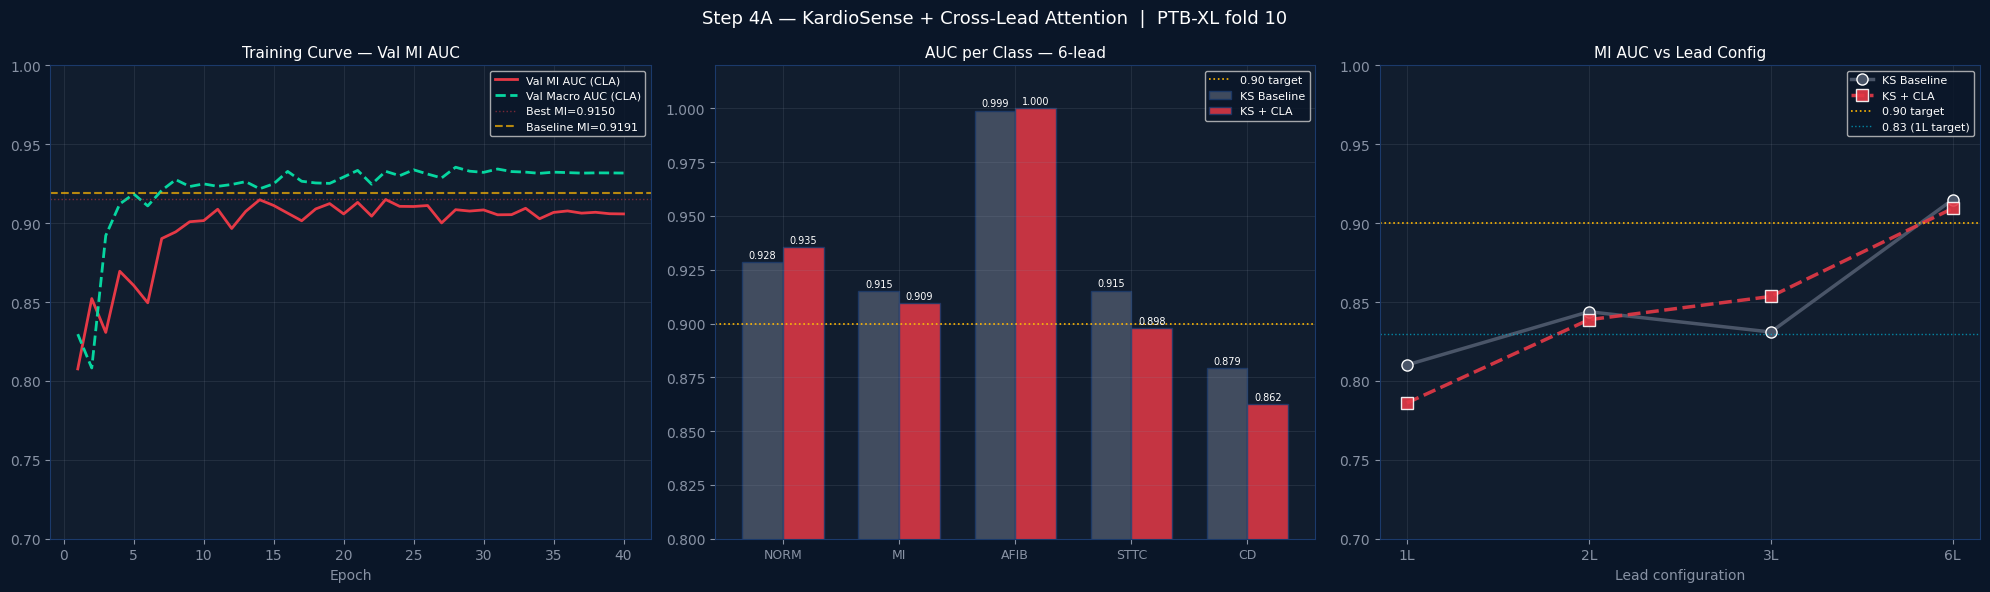

✅ Saved → /content/drive/MyDrive/KardioSenseAI/logs/step4a_cla_results.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), facecolor='#0A1628')
fig.suptitle('Step 4A — KardioSense + Cross-Lead Attention | PTB-XL fold 10',
 color='white', fontsize=13)

COLORS = {'NORM':'#06D6A0','MI':'#E63946','AFIB':'#00B4D8','STTC':'#FFB703','CD':'#A8DADC'}

for ax in axes:
 ax.set_facecolor('#111D2E')
 for s in ax.spines.values(): s.set_edgecolor('#1B3A6B')
 ax.tick_params(colors='#8892A4')
 ax.grid(True, alpha=0.15, color='#8892A4')

# ── Left: Val MI AUC training curve ───────────────────────────────────────
ax = axes[0]
epochs = range(1, N_EPOCHS+1)
ax.plot(epochs, history['val_mi_auc'], color='#E63946', lw=2, label='Val MI AUC (CLA)')
ax.plot(epochs, history['val_macro_auc'], color='#06D6A0', lw=2, label='Val Macro AUC (CLA)', ls='--')
ax.axhline(best_mi, color='#E63946', lw=1, ls=':', alpha=0.5, label=f'Best MI={best_mi:.4f}')
# Load baseline best MI from checkpoint
ckpt_base = torch.load(f'{CKPT_DIR}/kardiosense_ecg_best_mi.pt', map_location='cpu', weights_only=True)
ax.axhline(ckpt_base['mi_auc'], color='#FFB703', lw=1.5, ls='--', alpha=0.7,
 label=f'Baseline MI={ckpt_base["mi_auc"]:.4f}')
ax.set_title('Training Curve — Val MI AUC', color='white', fontsize=11)
ax.set_xlabel('Epoch', color='#8892A4'); ax.set_ylim(0.7, 1.0)
ax.legend(facecolor='#0A1628', labelcolor='white', fontsize=8)

# ── Middle: AUC comparison bar chart ─────────────────────────────────────
ax = axes[1]
x = np.arange(len(LABEL_NAMES))
w = 0.35
base_aucs = [baseline_6l.get(lbl,{}).get('auc',0) if isinstance(baseline_6l.get(lbl,{}),dict) else 0
 for lbl in LABEL_NAMES]
cla_aucs = [test_aucs_cla.get(lbl, 0) for lbl in LABEL_NAMES]

b1 = ax.bar(x-w/2, base_aucs, w, label='KS Baseline', color='#4A5568', alpha=0.85, edgecolor='#1B3A6B')
b2 = ax.bar(x+w/2, cla_aucs, w, label='KS + CLA', color='#E63946', alpha=0.85, edgecolor='#1B3A6B')
for bar,v in zip(b1, base_aucs):
 ax.text(bar.get_x()+bar.get_width()/2, v+0.002, f'{v:.3f}',
 ha='center', color='white', fontsize=7)
for bar,v in zip(b2, cla_aucs):
 ax.text(bar.get_x()+bar.get_width()/2, v+0.002, f'{v:.3f}',
 ha='center', color='white', fontsize=7)
ax.axhline(0.90, color='#FFB703', lw=1.2, ls=':', label='0.90 target')
ax.set_xticks(x); ax.set_xticklabels(LABEL_NAMES, color='#8892A4', fontsize=9)
ax.set_ylim(0.80, 1.02); ax.set_title('AUC per Class — 6-lead', color='white', fontsize=11)
ax.legend(facecolor='#0A1628', labelcolor='white', fontsize=8)

# ── Right: Lead ablation comparison — MI AUC ──────────────────────────────
ax = axes[2]
labels = ['1L','2L','3L','6L']
x_pos = np.arange(len(labels))

base_mi_vals = [baseline_ablation[s].get('MI',{}).get('auc',np.nan)
 if isinstance(baseline_ablation[s].get('MI',{}),dict) else np.nan
 for s in labels]
cla_mi_vals = [cla_ablation[s].get('MI',np.nan) for s in labels]

ax.plot(x_pos, base_mi_vals, 'o-', color='#4A5568', lw=2.5, ms=8,
 markeredgecolor='white', label='KS Baseline')
ax.plot(x_pos, cla_mi_vals, 's--', color='#E63946', lw=2.5, ms=8,
 markeredgecolor='white', label='KS + CLA', alpha=0.9)
ax.axhline(0.90, color='#FFB703', lw=1.2, ls=':', label='0.90 target')
ax.axhline(0.83, color='#00B4D8', lw=1.0, ls=':', label='0.83 (1L target)', alpha=0.7)
ax.set_xticks(x_pos); ax.set_xticklabels(labels, color='#8892A4')
ax.set_ylim(0.70, 1.0)
ax.set_title('MI AUC vs Lead Config', color='white', fontsize=11)
ax.set_xlabel('Lead configuration', color='#8892A4')
ax.legend(facecolor='#0A1628', labelcolor='white', fontsize=8)

plt.tight_layout()
plt.savefig(f'{LOG_DIR}/step4a_cla_results.png', dpi=130,
 bbox_inches='tight', facecolor='#0A1628')
plt.show()
print(f' Saved → {LOG_DIR}/step4a_cla_results.png')


## 8. Save & Step 4A Summary

In [10]:
def s(v):
 if isinstance(v,(float,np.floating)): return None if np.isnan(v) else float(v)
 if isinstance(v,(int,np.integer)): return int(v)
 if isinstance(v,dict): return {k:s(vv) for k,vv in v.items()}
 return v

results_4a = {
 'meta': {
 'experiment' : 'Step4A_CrossLeadAttention',
 'dataset' : 'PTB-XL', 'test_fold': 10,
 'label_names' : LABEL_NAMES,
 'cla_heads' : 2,
 'training_epochs': N_EPOCHS,
 'best_val_mi_auc': float(best_mi),
 },
 'test_6lead': {
 'ks_baseline': {lbl: {'auc': s(baseline_6l.get(lbl,{}).get('auc',float('nan'))
 if isinstance(baseline_6l.get(lbl,{}),dict) else float('nan'))}
 for lbl in LABEL_NAMES+['MACRO']},
 'ks_cla' : {lbl: {'auc': s(test_aucs_cla.get(lbl,float('nan')))}
 for lbl in LABEL_NAMES+['MACRO']},
 },
 'lead_ablation_mi_auc': {
 short: {'ks_baseline': s(baseline_ablation[short].get('MI',{}).get('auc',float('nan'))
 if isinstance(baseline_ablation[short].get('MI',{}),dict) else float('nan')),
 'ks_cla' : s(cla_ablation[short].get('MI',float('nan')))}
 for short in ABLATION_SLOTS
 },
}

out = f'{BENCH_DIR}/results_step4a.json'
with open(out,'w') as f: json.dump(results_4a, f, indent=2)
print(f' Results saved → {out}')
print()
print('Step 4A complete. Key questions answered:')
print(' 1. Does CLA improve 6-lead AUC on NORM/STTC/CD? → see AUC bar chart')
print(' 2. Does CLA preserve 1-lead robustness? → see lead ablation')
print(' 3. Is CLA worth the +~8K param overhead? → compare delta vs Step 4B')
print()
print('Next: KardioSense_06b_Step4B_12Lead.ipynb')
print(' Retrain the full architecture with n_leads=12 and compare to ISIBrno native.')


✅ Results saved → /content/drive/MyDrive/KardioSenseAI/benchmark/results_step4a.json

Step 4A complete. Key questions answered:
  1. Does CLA improve 6-lead AUC on NORM/STTC/CD?  → see AUC bar chart
  2. Does CLA preserve 1-lead robustness?          → see lead ablation
  3. Is CLA worth the +~8K param overhead?         → compare delta vs Step 4B

Next: KardioSense_06b_Step4B_12Lead.ipynb
  Retrain the full architecture with n_leads=12 and compare to ISIBrno native.
